In [ ]:
pip install -Uq langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.7/506.7 kB 8.1 MB/s eta 0:00:00


In [ ]:
import os
os.environ['LANGSMITH_TRACING'] ='true'
os.environ['LANGSMITH_ENDPOINT']='https://api.smith.langchain.com'
os.environ['LANGSMITH_API_KEY']='<langsmith key>'
os.environ['LANGSMITH_PROJECT']="ai-agents-day2"

In [ ]:
import getpass
import os

os.environ["AZURE_OPENAI_API_KEY"] = "<openai key>"
os.environ["AZURE_OPENAI_ENDPOINT"] = "https://ai-engineering-vidvatta1.openai.azure.com/"
os.environ["AZURE_DEPLOYMENT"]="gpt-5.4-mini"  # or your deployment
os.environ["API_VERSION"]="2025-04-01-preview"

from langchain_openai import AzureChatOpenAI

llm = AzureChatOpenAI(
    azure_deployment=os.environ["AZURE_DEPLOYMENT"],  # or your deployment
    api_version=os.environ["API_VERSION"])

llm.invoke('hello')

AIMessage(content='Hello! How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 7, 'total_tokens': 20, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DOceukmwLZxmeZoxAjlI7ZO8UTIrN', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'detected': False, 'filtered': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}], 'finish_reason': 'stop', 'logprobs': None, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'pr

In [ ]:
from datetime import datetime
def get_current_datetime():
  """Gives current date and time"""
  return datetime.now()

def add_two_numbers(num1: int, num2: int) -> int:
  """Addition of two numbers"""
  return num1 + num2



In [ ]:
from langchain.agents import create_agent
agent = create_agent(llm, tools=[get_current_datetime, add_two_numbers])
response = agent.invoke({
    'messages': "give me current date time and and what will be the date 5 days before"
})

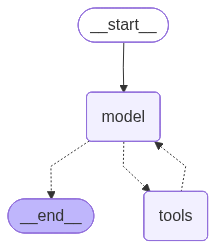

In [ ]:
from IPython.display import Image, display

try:
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [ ]:
response

{'messages': [HumanMessage(content='give me current date time and and what will be the date 5 days before', additional_kwargs={}, response_metadata={}, id='8d795e80-7c15-4597-ab70-3ddd87ceef90'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 161, 'total_tokens': 176, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DOdEax3Ld69GpbhyCdNBsPi1ERVJs', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'detected': False, 'filtered': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence

In [ ]:
from langchain.messages import HumanMessage, SystemMessage, ToolMessage

In [ ]:
messages = []
while True:
  user_input = input("Enter your query")
  if user_input == "exit":
    break
  messages.append(HumanMessage(content=user_input))
  response = llm.invoke(messages)
  print(response)
  messages.append(response)
  print(messages)

Enter your queryexit\
content='Goodbye.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 7, 'prompt_tokens': 8, 'total_tokens': 15, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DOd0DhUPJHD2PJV0NHSpe78Ppu8P4', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'detected': False, 'filtered': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}], 'finish_reason': 'stop', 'logprobs': None, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'protected_materia

In [ ]:
from langchain.tools import tool
from datetime import datetime

@tool
def get_current_datetime():
  """Gives current date and time"""
  return datetime.now()

@tool
def add_two_numbers(num1: int, num2: int) -> int:
  """Addition of two numbers"""
  return num1 + num2

tool_reference = {
    'get_current_datetime': get_current_datetime,
    'add_two_numbers': add_two_numbers
}


In [ ]:
from langchain_core.utils.function_calling import convert_to_openai_tool

convert_to_openai_tool(add_two_numbers)

{'type': 'function',
 'function': {'name': 'add_two_numbers',
  'description': 'Addition of two numbers',
  'parameters': {'properties': {'num1': {'type': 'integer'},
    'num2': {'type': 'integer'}},
   'required': ['num1', 'num2'],
   'type': 'object'}}}

In [ ]:
llm_with_tools = llm.bind_tools([get_current_datetime, add_two_numbers])

In [ ]:
response = llm_with_tools.invoke('give me addition of 32432 and 33243')

In [ ]:
tool_name = response.tool_calls[0]['name']
tool_args = response.tool_calls[0]['args']
tool_name, tool_args

('add_two_numbers', {'num1': 32432, 'num2': 33243})

In [ ]:
tool_args

{'num1': 32432, 'num2': 33243}

In [ ]:
tool_response = tool_reference[tool_name].invoke(tool_args)

In [ ]:
ToolMessage(content=str(tool_response))

KeyError: 'tool_call_id'

In [ ]:
messages = [SystemMessage(content='you are a helpful assistant WHO CAN ONLY answer questions related to medical advice and NOTHING ELSE, also with tool calls if it is related then only call, else say we cannot answer this question')]
messages.append(HumanMessage(content = 'give me current date time and and what will be the date 5 days before'))
while True:
  # call llm with list of messages
  response = llm_with_tools.invoke(messages)

  # add the llm response / AI Message to the messages
  messages.append(response)

  # check if tool calls are present
  if response.tool_calls:
    print(response.tool_calls)
    # loop through the tool calls sent by llm
    for tool_call in response.tool_calls:

      # get details of tools to be called with arguments
      tool_name = response.tool_calls[0]['name']
      tool_args = response.tool_calls[0]['args']

      # call the tool / function with arguments shared by llm
      tool_response = tool_reference[tool_name].invoke(tool_args)

      # add the response of tool call to the messages
      messages.append(ToolMessage(content=str(tool_response), name=tool_name, tool_call_id=tool_call['id']))
  else:
    print(response)
    break

[{'name': 'get_current_datetime', 'args': {}, 'id': 'call_xxeQ2qYAxz6IbI7rqySNhBEp', 'type': 'tool_call'}]
content='Current date and time: **2026-03-29 06:02:00**\n\nFive days before that date is: **2026-03-24**' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 243, 'total_tokens': 281, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DOdVg6nTAe7emtA6CW3fL8t3yUiSm', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {}}], 'finish_reason': 'stop', 'logprobs': None, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'protected_material_code': {'detected': False, 'filtered': False}, 'protected_material_text': {'dete

In [ ]:
messages

[SystemMessage(content='you are a helpful assistant WHO CAN ONLY answer questions related to medical advice and NOTHING ELSE, also with tool calls if it is related then only call, else say we cannot answer this question', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='give me current date time and and what will be the date 5 days before', additional_kwargs={}, response_metadata={}),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 202, 'total_tokens': 217, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DOdVfBtbYOk57WKM3QGoj3W3kJFNq', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate'

## LangGraph

In [ ]:
from typing import Annotated, Literal, Sequence, TypedDict
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]
    response: str

def node1(state):
  print(state)
  input_query = state['messages'][-1]
  response = llm.invoke(state['messages'])
  return {'messages': [response]}

def node2(state):
  print(state)
  input_query = state['messages'][-1]
  return {'messages': [input_query.content.upper()], 'response': input_query.content.upper()}



In [ ]:
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(AgentState)

workflow.add_node("llm", node1)
workflow.add_node("upper", node2)

workflow.add_edge(START, "llm")
workflow.add_edge("llm", "upper")
workflow.add_edge("upper", END)

graph = workflow.compile()

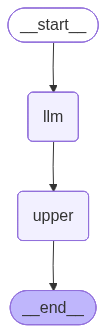

In [ ]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [ ]:
response = graph.invoke({
  'messages': ['ai agents in 1 sentence'],
  'response': ""
})

{'messages': [HumanMessage(content='ai agents in 1 sentence', additional_kwargs={}, response_metadata={}, id='75cc2784-3b97-4d06-adae-56180c73063f')], 'response': ''}
{'messages': [HumanMessage(content='ai agents in 1 sentence', additional_kwargs={}, response_metadata={}, id='75cc2784-3b97-4d06-adae-56180c73063f'), AIMessage(content='AI agents are software systems that can perceive their environment, make decisions, and take actions autonomously to achieve specific goals.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 12, 'total_tokens': 40, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DOeGAoBeh8HyldHt9gvX6nA9E6hXK', 'prompt_filter_results': [{'prom

In [ ]:
response

{'messages': [HumanMessage(content='ai agents in 1 sentence', additional_kwargs={}, response_metadata={}, id='75cc2784-3b97-4d06-adae-56180c73063f'),
  AIMessage(content='AI agents are software systems that can perceive their environment, make decisions, and take actions autonomously to achieve specific goals.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 12, 'total_tokens': 40, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DOeGAoBeh8HyldHt9gvX6nA9E6hXK', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'detected': False, 'filtered': False}, 'self_harm': {'filtere

In [ ]:
response = graph.invoke({
  'messages': ['give me some use cases of those'],
  'response': ""
})

{'messages': [HumanMessage(content='give me some use cases of those', additional_kwargs={}, response_metadata={}, id='8b331d28-667a-44a2-b48b-b0b641c8d5f5')], 'response': ''}
{'messages': [HumanMessage(content='give me some use cases of those', additional_kwargs={}, response_metadata={}, id='8b331d28-667a-44a2-b48b-b0b641c8d5f5'), AIMessage(content='Sure — but I need a bit more context. What does **“those”** refer to?\n\nIf you paste the item, tool, concept, or list you mean, I can give you use cases for it.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 13, 'total_tokens': 61, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DOeQl2Gkx5J3gmas5ElbnRSN5h5

In [ ]:
response

{'messages': [HumanMessage(content='give me some use cases of those', additional_kwargs={}, response_metadata={}, id='8b331d28-667a-44a2-b48b-b0b641c8d5f5'),
  AIMessage(content='Sure — but I need a bit more context. What does **“those”** refer to?\n\nIf you paste the item, tool, concept, or list you mean, I can give you use cases for it.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 13, 'total_tokens': 61, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DOeQl2Gkx5J3gmas5ElbnRSN5h5Rp', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'detected': False, 'filtered': F

## Memory

In [ ]:
from langgraph.checkpoint.memory import InMemorySaver
checkpointer = InMemorySaver()

graph = workflow.compile(checkpointer=checkpointer)

In [ ]:
config = {"configurable": {"thread_id": "1"}}
graph.invoke({
  'messages': ['ai agents in 1 sentence'],
  'response': ""
}, config)

{'messages': [HumanMessage(content='ai agents in 1 sentence', additional_kwargs={}, response_metadata={}, id='afdf1556-33f0-48ad-91cf-67d7b8802330')], 'response': ''}
{'messages': [HumanMessage(content='ai agents in 1 sentence', additional_kwargs={}, response_metadata={}, id='afdf1556-33f0-48ad-91cf-67d7b8802330'), AIMessage(content='AI agents are software systems that perceive their environment, make decisions, and take actions autonomously to achieve specific goals.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 12, 'total_tokens': 39, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DOeUSYl0JIp8tNBUbrRga2s3bXXFz', 'prompt_filter_results': [{'prompt_i

{'messages': [HumanMessage(content='ai agents in 1 sentence', additional_kwargs={}, response_metadata={}, id='afdf1556-33f0-48ad-91cf-67d7b8802330'),
  AIMessage(content='AI agents are software systems that perceive their environment, make decisions, and take actions autonomously to achieve specific goals.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 12, 'total_tokens': 39, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DOeUSYl0JIp8tNBUbrRga2s3bXXFz', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'detected': False, 'filtered': False}, 'self_harm': {'filtered': 

In [ ]:
graph.invoke({
  'messages': ['what are some use cases in banking for those'],
  'response': ""
}, config)

{'messages': [HumanMessage(content='ai agents in 1 sentence', additional_kwargs={}, response_metadata={}, id='afdf1556-33f0-48ad-91cf-67d7b8802330'), AIMessage(content='AI agents are software systems that perceive their environment, make decisions, and take actions autonomously to achieve specific goals.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 12, 'total_tokens': 39, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DOeUSYl0JIp8tNBUbrRga2s3bXXFz', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'detected': False, 'filtered': False}, 'self_harm': {'filtered': Fa

{'messages': [HumanMessage(content='ai agents in 1 sentence', additional_kwargs={}, response_metadata={}, id='afdf1556-33f0-48ad-91cf-67d7b8802330'),
  AIMessage(content='AI agents are software systems that perceive their environment, make decisions, and take actions autonomously to achieve specific goals.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 12, 'total_tokens': 39, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DOeUSYl0JIp8tNBUbrRga2s3bXXFz', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'detected': False, 'filtered': False}, 'self_harm': {'filtered': 

In [ ]:
config = {"configurable": {"thread_id": "2"}}
graph.invoke({
  'messages': ['what are some use cases in banking for those'],
  'response': ""
}, config)

{'messages': [HumanMessage(content='what are some use cases in banking for those', additional_kwargs={}, response_metadata={}, id='c53503fe-5f93-4b4b-a47e-dee0d9df2802')], 'response': ''}
{'messages': [HumanMessage(content='what are some use cases in banking for those', additional_kwargs={}, response_metadata={}, id='c53503fe-5f93-4b4b-a47e-dee0d9df2802'), AIMessage(content='Could you clarify what “those” refers to?\n\nIf you mean **AI/LLMs**, common banking use cases include:\n- **Customer support/chatbots** for account questions, card issues, and FAQs\n- **Fraud detection support** by analyzing alerts and customer behavior\n- **KYC/AML assistance** for reviewing documents and flagging anomalies\n- **Loan underwriting** to summarize applicant data and help with decisions\n- **Compliance and policy search** across regulations and internal procedures\n- **Agent-assist tools** for call center reps during customer conversations\n- **Personalized banking insights** like spending summaries 

{'messages': [HumanMessage(content='what are some use cases in banking for those', additional_kwargs={}, response_metadata={}, id='c53503fe-5f93-4b4b-a47e-dee0d9df2802'),
  AIMessage(content='Could you clarify what “those” refers to?\n\nIf you mean **AI/LLMs**, common banking use cases include:\n- **Customer support/chatbots** for account questions, card issues, and FAQs\n- **Fraud detection support** by analyzing alerts and customer behavior\n- **KYC/AML assistance** for reviewing documents and flagging anomalies\n- **Loan underwriting** to summarize applicant data and help with decisions\n- **Compliance and policy search** across regulations and internal procedures\n- **Agent-assist tools** for call center reps during customer conversations\n- **Personalized banking insights** like spending summaries and savings suggestions\n- **Document processing** for statements, forms, IDs, and contracts\n\nIf you mean something else by “those,” tell me what you’re referring to and I’ll tailor th

In [ ]:
graph.invoke({
  'messages': ['ai agents'],
  'response': ""
}, config)

{'messages': [HumanMessage(content='what are some use cases in banking for those', additional_kwargs={}, response_metadata={}, id='c53503fe-5f93-4b4b-a47e-dee0d9df2802'), AIMessage(content='Could you clarify what “those” refers to?\n\nIf you mean **AI/LLMs**, common banking use cases include:\n- **Customer support/chatbots** for account questions, card issues, and FAQs\n- **Fraud detection support** by analyzing alerts and customer behavior\n- **KYC/AML assistance** for reviewing documents and flagging anomalies\n- **Loan underwriting** to summarize applicant data and help with decisions\n- **Compliance and policy search** across regulations and internal procedures\n- **Agent-assist tools** for call center reps during customer conversations\n- **Personalized banking insights** like spending summaries and savings suggestions\n- **Document processing** for statements, forms, IDs, and contracts\n\nIf you mean something else by “those,” tell me what you’re referring to and I’ll tailor the 

{'messages': [HumanMessage(content='what are some use cases in banking for those', additional_kwargs={}, response_metadata={}, id='c53503fe-5f93-4b4b-a47e-dee0d9df2802'),
  AIMessage(content='Could you clarify what “those” refers to?\n\nIf you mean **AI/LLMs**, common banking use cases include:\n- **Customer support/chatbots** for account questions, card issues, and FAQs\n- **Fraud detection support** by analyzing alerts and customer behavior\n- **KYC/AML assistance** for reviewing documents and flagging anomalies\n- **Loan underwriting** to summarize applicant data and help with decisions\n- **Compliance and policy search** across regulations and internal procedures\n- **Agent-assist tools** for call center reps during customer conversations\n- **Personalized banking insights** like spending summaries and savings suggestions\n- **Document processing** for statements, forms, IDs, and contracts\n\nIf you mean something else by “those,” tell me what you’re referring to and I’ll tailor th

In [ ]:
## LangGraph